# 2.7 - GDELT Historical Data Merge (1979-2013)

**Objetivo:** Procesar el archivo histórico `GDELT.MASTERREDUCEDV2.TXT` y empalmarlo con los datos de GDELT 2.0 (2015-2025) descargados con BigQuery.

**Fuentes:**
- GDELT 1.0: `GDELT.MASTERREDUCEDV2.TXT` (1979-2013, 6.3 GB)
- GDELT 2.0: `sentiment_daily_2000_2025.csv` (2015-2025, BigQuery)

**Output:**
- `sentiment_daily_1979_2025_merged.csv` - Dataset completo con 46 años de datos

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc

# Configuración
PROJECT_ROOT = Path.cwd().parents[1]
DATA_EXTERNAL = PROJECT_ROOT / 'data' / 'external' / 'sentiment'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data external: {DATA_EXTERNAL}")
print(f"Data processed: {DATA_PROCESSED}")

Project root: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
Data external: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\external\sentiment
Data processed: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed


## 1. Explorar estructura del archivo GDELT 1.0

Primero necesitamos entender la estructura del archivo MASTERREDUCEDV2.

In [2]:
# Verificar archivo
gdelt_v1_file = DATA_EXTERNAL / 'GDELT.MASTERREDUCEDV2.TXT'
print(f"Archivo: {gdelt_v1_file}")
print(f"Existe: {gdelt_v1_file.exists()}")
print(f"Tamaño: {gdelt_v1_file.stat().st_size / 1e9:.2f} GB")

# Leer primeras líneas para entender estructura
with open(gdelt_v1_file, 'r', encoding='utf-8', errors='ignore') as f:
    for i in range(10):
        line = f.readline()
        print(f"Line {i}: {line[:150]}...")  # Primeros 150 chars

Archivo: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\external\sentiment\GDELT.MASTERREDUCEDV2.TXT
Existe: True
Tamaño: 6.58 GB
Line 0: Date	Source	Target	CAMEOCode	NumEvents	NumArts	QuadClass	Goldstein	SourceGeoType	SourceGeoLat	SourceGeoLong	TargetGeoType	TargetGeoLat	TargetGeoLong	A...
Line 1: 19790101	AFR	FRA	043	1	4	1	2.8			
...
Line 2: 19790101	AFR	FRA	050	2	9	1	3.5									
...
Line 3: 19790101	AFR	FRAGOV	043	2	19	1	2.8	1	46	2	1	46	2	1	46	2
...
Line 4: 19790101	AFR	ZMB	100	2	18	3	-5									
...
Line 5: 19790101	ARG	ARGGOVMIL	172	1	4	4	-5	4	-14.4432	28.4517	4	-14.4432	28.4517	4	-14.4432	28.4517
...
Line 6: 19790101	ARG	CHL	172	2	4	4	-5	1	-34	-64	1	-30	-71	1	-34	-64
...
Line 7: 19790101	ARG	VATGOV	072	1	4	2	8.3	1	-34	-64	1	-34	-64	1	-34	-64
...
Line 8: 19790101	ATH	MOSGOV	120	1	2	3	-4	1	-34	-64	1	-34	-64	1	-34	-64
...
Line 9: 19790101	ATH	RUS	120	2	5	3	-4							4	55.7522	37.6156
...


## 2. Definir columnas del archivo GDELT 1.0

Según la documentación de GDELT MASTERREDUCED:
- Date (YYYYMMDD)
- Source Actor
- Target Actor  
- CAMEO Code
- NumEvents
- NumArts (Number of Articles)
- QuadClass (Event type: Verbal Coop, Material Coop, Verbal Conflict, Material Conflict)
- Goldstein Scale (-10 to +10, conflict vs cooperation)
- SourceGeoType, SourceGeoLat, SourceGeoLong
- TargetGeoType, TargetGeoLat, TargetGeoLong
- ActionGeoType, ActionGeoLat, ActionGeoLong

In [3]:
# Columnas del archivo GDELT MASTERREDUCED V2
columns = [
    'Date',
    'Source',
    'Target',
    'CAMEOCode',
    'NumEvents',
    'NumArts',
    'QuadClass',
    'Goldstein',
    'SourceGeoType',
    'SourceGeoLat',
    'SourceGeoLong',
    'TargetGeoType',
    'TargetGeoLat',
    'TargetGeoLong',
    'ActionGeoType',
    'ActionGeoLat',
    'ActionGeoLong'
]

print(f"Columnas esperadas: {len(columns)}")
print(columns)

Columnas esperadas: 17
['Date', 'Source', 'Target', 'CAMEOCode', 'NumEvents', 'NumArts', 'QuadClass', 'Goldstein', 'SourceGeoType', 'SourceGeoLat', 'SourceGeoLong', 'TargetGeoType', 'TargetGeoLat', 'TargetGeoLong', 'ActionGeoType', 'ActionGeoLat', 'ActionGeoLong']


## 3. Leer archivo en chunks (6.3 GB es muy grande)

Para no explotar la RAM, vamos a:
1. Leer el archivo en chunks de 1M filas
2. Agregar cada chunk por día
3. Acumular en un diccionario
4. Al final, consolidar todo

In [4]:
# Función para calcular tone aproximado desde Goldstein
# GDELT 1.0 no tiene tone directo, pero Goldstein es similar
# Goldstein: -10 (muy negativo) a +10 (muy positivo)
# Vamos a normalizarlo a escala [-1, 1] como en GDELT 2.0

def goldstein_to_tone(goldstein):
    """Convierte Goldstein Scale (-10 a +10) a Tone (-1 a +1)"""
    return goldstein / 10.0

print("Función goldstein_to_tone lista")
print(f"Ejemplo: Goldstein=5 → Tone={goldstein_to_tone(5)}")
print(f"Ejemplo: Goldstein=-8 → Tone={goldstein_to_tone(-8)}")

Función goldstein_to_tone lista
Ejemplo: Goldstein=5 → Tone=0.5
Ejemplo: Goldstein=-8 → Tone=-0.8


In [6]:
# Procesar archivo en chunks
chunk_size = 1_000_000  # 1M filas por chunk
daily_data = {}  # {date: [tone_values]}

print(f"Leyendo {gdelt_v1_file.name}...")
print(f"Chunk size: {chunk_size:,} filas")
print("Esto puede tomar 5-10 minutos...\n")

# Leer en chunks con progress bar
chunk_count = 0
total_rows = 0

try:
    for chunk in tqdm(pd.read_csv(
        gdelt_v1_file,
        sep='\t',
        names=columns,
        header=0,  # Saltar primera fila (header)
        chunksize=chunk_size,
        low_memory=False,
        encoding='utf-8',
        on_bad_lines='skip'  # Saltar líneas problemáticas
    ), desc="Procesando chunks"):
        
        chunk_count += 1
        total_rows += len(chunk)
        
        # Filtrar solo filas con Date y Goldstein válidos
        chunk_clean = chunk[['Date', 'Goldstein', 'NumArts']].copy()
        chunk_clean = chunk_clean.dropna(subset=['Date', 'Goldstein'])
        
        # Convertir Date a string de 8 dígitos
        chunk_clean['Date'] = chunk_clean['Date'].astype(str).str.zfill(8)
        
        # Convertir Goldstein a numérico primero (por si viene como string)
        chunk_clean['Goldstein'] = pd.to_numeric(chunk_clean['Goldstein'], errors='coerce')
        chunk_clean = chunk_clean.dropna(subset=['Goldstein'])
        
        # Convertir Goldstein a tone
        chunk_clean['tone'] = chunk_clean['Goldstein'] / 10.0
        
        # Agregar por día
        for date_str, group in chunk_clean.groupby('Date'):
            if date_str not in daily_data:
                daily_data[date_str] = []
            
            # Agregar todos los tones de este día
            daily_data[date_str].extend(group['tone'].tolist())
        
        # Liberar memoria cada 5 chunks
        if chunk_count % 5 == 0:
            gc.collect()
            print(f"  Chunk {chunk_count}: {total_rows:,} filas procesadas, {len(daily_data):,} días únicos")

except Exception as e:
    print(f"\n⚠️  Error en chunk {chunk_count}: {e}")
    print(f"   Continuando con {len(daily_data)} días ya procesados...")

print(f"\n✅ Lectura completada:")
print(f"   Chunks procesados: {chunk_count}")
print(f"   Filas totales: {total_rows:,}")
print(f"   Días únicos: {len(daily_data):,}")

Leyendo GDELT.MASTERREDUCEDV2.TXT...
Chunk size: 1,000,000 filas
Esto puede tomar 5-10 minutos...



Procesando chunks: 5it [00:11,  2.25s/it]

  Chunk 5: 5,000,000 filas procesadas, 4,351 días únicos


Procesando chunks: 10it [00:22,  2.29s/it]

  Chunk 10: 10,000,000 filas procesadas, 6,623 días únicos


...

  Chunk 80: 80,000,000 filas procesadas, 12,630 días únicos


Procesando chunks: 85it [02:53,  2.35s/it]

  Chunk 85: 85,000,000 filas procesadas, 12,758 días únicos


Procesando chunks: 88it [02:58,  2.03s/it]


✅ Lectura completada:
   Chunks procesados: 88
   Filas totales: 87,298,046
   Días únicos: 12,833


## 4. Consolidar datos diarios de GDELT 1.0

In [7]:
# Convertir diccionario a DataFrame agregado
print(f"Consolidando {len(daily_data):,} días...")

daily_rows_v1 = []
for date_str, tones in tqdm(daily_data.items(), desc="Agregando por día"):
    daily_rows_v1.append({
        'date': pd.to_datetime(date_str, format='%Y%m%d', errors='coerce'),
        'tone_mean': np.mean(tones),
        'tone_std': np.std(tones) if len(tones) > 1 else 0,
        'tone_count': len(tones),
        'article_count': len(tones),  # Aproximación
        'source': 'GDELT_v1'
    })

df_gdelt_v1 = pd.DataFrame(daily_rows_v1)
df_gdelt_v1 = df_gdelt_v1.dropna(subset=['date'])
df_gdelt_v1 = df_gdelt_v1.sort_values('date').reset_index(drop=True)

# Liberar memoria
del daily_data
del daily_rows_v1
gc.collect()

print(f"\n✅ GDELT 1.0 consolidado:")
print(f"   Días con datos: {len(df_gdelt_v1):,}")
print(f"   Rango: {df_gdelt_v1['date'].min().date()} a {df_gdelt_v1['date'].max().date()}")
print(f"   Tone medio: {df_gdelt_v1['tone_mean'].mean():.3f}")
print(f"\nPrimeras filas:")
display(df_gdelt_v1.head(10))

Consolidando 12,833 días...


Agregando por día: 100%|██████████| 12833/12833 [00:11<00:00, 1120.62it/s]




✅ GDELT 1.0 consolidado:
   Días con datos: 12,833
   Rango: 1979-01-01 a 2014-02-18
   Tone medio: 0.061

Primeras filas:


,date,tone_mean,tone_std,tone_count,article_count,source
0,1979-01-01,0.089608,0.488608,306,306,GDELT_v1
1,1979-01-02,-0.011824,0.508529,433,433,GDELT_v1
2,1979-01-03,0.098256,0.472638,516,516,GDELT_v1
3,1979-01-04,0.091844,0.453492,488,488,GDELT_v1
4,1979-01-05,0.116867,0.445045,482,482,GDELT_v1
5,1979-01-06,0.070636,0.481501,330,330,GDELT_v1
6,1979-01-07,0.148399,0.386917,406,406,GDELT_v1
7,1979-01-08,0.127196,0.411229,624,624,GDELT_v1
8,1979-01-09,0.053034,0.448801,646,646,GDELT_v1
9,1979-01-10,0.125337,0.426594,624,624,GDELT_v1


## 5. Cargar datos GDELT 2.0 (BigQuery)

In [8]:
# Cargar datos de GDELT 2.0
gdelt_v2_file = DATA_EXTERNAL / 'sentiment_daily_2000_2025.csv'

print(f"Cargando GDELT 2.0: {gdelt_v2_file.name}")
df_gdelt_v2 = pd.read_csv(gdelt_v2_file, parse_dates=['date'])
df_gdelt_v2['source'] = 'GDELT_v2'

print(f"\n✅ GDELT 2.0 cargado:")
print(f"   Días con datos: {len(df_gdelt_v2):,}")
print(f"   Rango: {df_gdelt_v2['date'].min().date()} a {df_gdelt_v2['date'].max().date()}")
print(f"   Tone medio: {df_gdelt_v2['tone_mean'].mean():.3f}")
print(f"\nPrimeras filas:")
display(df_gdelt_v2.head(10))

Cargando GDELT 2.0: sentiment_daily_2000_2025.csv

✅ GDELT 2.0 cargado:
   Días con datos: 3,920
   Rango: 2015-02-19 a 2025-11-30
   Tone medio: -0.006

Primeras filas:


,date,tone_mean,tone_std,tone_count,article_count,source
0,2015-02-19,-0.009066,0.032156,21099,21099,GDELT_v2
1,2015-02-20,-0.006407,0.030327,22744,22744,GDELT_v2
2,2015-02-21,-0.007508,0.032169,16162,16162,GDELT_v2
3,2015-02-22,-0.007297,0.030250,17002,17002,GDELT_v2
4,2015-02-23,-0.008316,0.031186,26952,26952,GDELT_v2
5,2015-02-24,-0.009919,0.032368,30049,30049,GDELT_v2
6,2015-02-25,-0.009938,0.033706,31260,31260,GDELT_v2
7,2015-02-26,-0.008380,0.032258,32491,32491,GDELT_v2
8,2015-02-27,-0.007697,0.031087,30603,30603,GDELT_v2
9,2015-02-28,-0.007217,0.029798,22095,22095,GDELT_v2


## 6. Merge de GDELT 1.0 + 2.0

Vamos a:
1. Unir ambos DataFrames
2. Resolver overlap (si hay fechas duplicadas)
3. Ordenar cronológicamente

In [9]:
# Verificar overlap
v1_dates = set(df_gdelt_v1['date'].dt.date)
v2_dates = set(df_gdelt_v2['date'].dt.date)
overlap_dates = v1_dates.intersection(v2_dates)

print(f"Análisis de overlap:")
print(f"  GDELT 1.0: {len(v1_dates):,} días ({min(v1_dates)} a {max(v1_dates)})")
print(f"  GDELT 2.0: {len(v2_dates):,} días ({min(v2_dates)} a {max(v2_dates)})")
print(f"  Overlap: {len(overlap_dates):,} días")

if len(overlap_dates) > 0:
    print(f"\n  Fechas en overlap: {sorted(overlap_dates)[:10]}...")
    print(f"  Estrategia: Priorizar GDELT 2.0 (más detallado)")

Análisis de overlap:
  GDELT 1.0: 12,833 días (1979-01-01 a 2014-02-18)
  GDELT 2.0: 3,920 días (2015-02-19 a 2025-11-30)
  Overlap: 0 días


In [10]:
# Merge strategy: Priorizar GDELT 2.0 para fechas duplicadas
print("Mergeando datasets...")

# Concatenar
df_merged = pd.concat([df_gdelt_v1, df_gdelt_v2], ignore_index=True)

# Ordenar por fecha y source (v2 primero)
df_merged = df_merged.sort_values(['date', 'source'], ascending=[True, False])

# Eliminar duplicados por fecha, manteniendo el primero (v2)
df_merged = df_merged.drop_duplicates(subset=['date'], keep='first')

# Ordenar y reset index
df_merged = df_merged.sort_values('date').reset_index(drop=True)

print(f"\n✅ Merge completado:")
print(f"   Días totales: {len(df_merged):,}")
print(f"   Rango: {df_merged['date'].min().date()} a {df_merged['date'].max().date()}")
print(f"   Años cubiertos: {(df_merged['date'].max() - df_merged['date'].min()).days / 365.25:.1f}")
print(f"\nDistribución por fuente:")
print(df_merged['source'].value_counts())

Mergeando datasets...

✅ Merge completado:
   Días totales: 16,753
   Rango: 1979-01-01 a 2025-11-30
   Años cubiertos: 46.9

Distribución por fuente:
source
GDELT_v1    12833
GDELT_v2     3920
Name: count, dtype: int64


## 7. Visualizar cobertura temporal

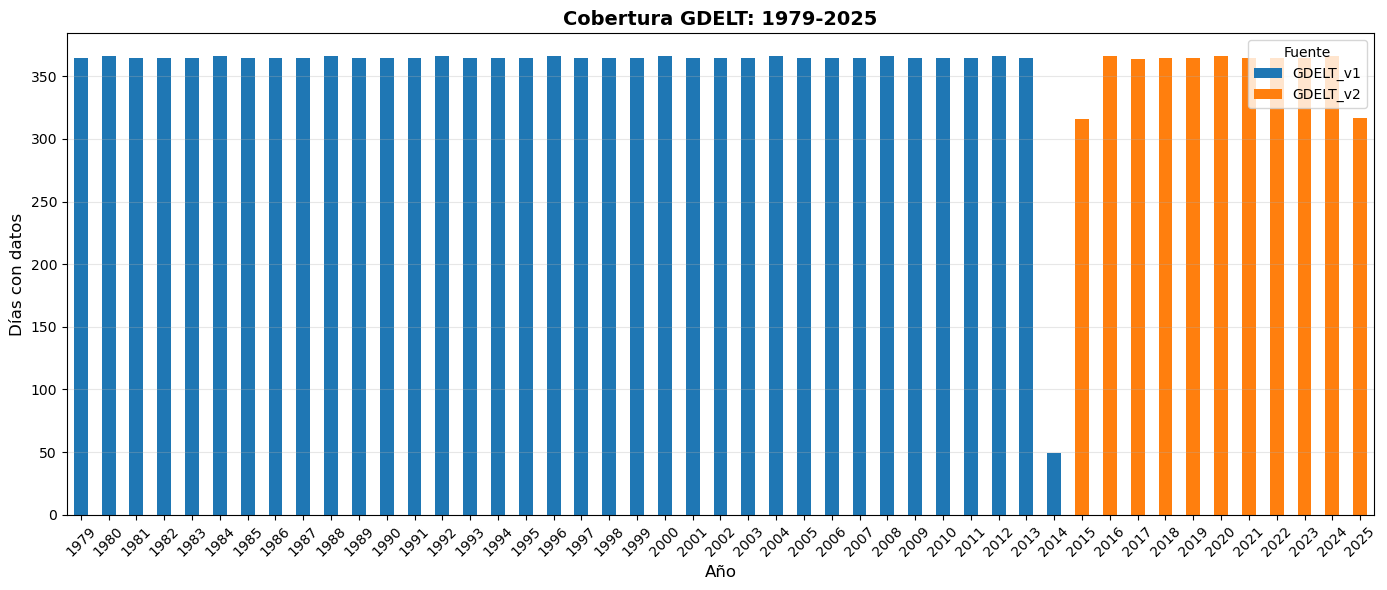


Resumen por década:


,days,avg_tone
decade,,
1970,365,0.104547
1980,3653,0.043923
1990,3652,0.086452
2000,3653,0.054440
2010,3286,0.017590
2020,2144,-0.005080


In [11]:
# Visualizar cobertura por año y fuente
df_merged['year'] = df_merged['date'].dt.year

coverage = df_merged.groupby(['year', 'source']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
coverage.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Cobertura GDELT: 1979-2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Días con datos', fontsize=12)
ax.legend(title='Fuente', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nResumen por década:")
df_merged['decade'] = (df_merged['year'] // 10) * 10
decade_summary = df_merged.groupby('decade').agg({
    'date': 'count',
    'tone_mean': 'mean'
}).rename(columns={'date': 'days', 'tone_mean': 'avg_tone'})
display(decade_summary)

## 8. Guardar dataset merged

In [12]:
# Guardar dataset completo
output_file = DATA_EXTERNAL / 'sentiment_daily_1979_2025_merged.csv'

print(f"Guardando dataset merged: {output_file.name}")
df_merged.to_csv(output_file, index=False)

print(f"\n✅ Archivo guardado:")
print(f"   Path: {output_file}")
print(f"   Tamaño: {output_file.stat().st_size / 1e6:.2f} MB")
print(f"   Filas: {len(df_merged):,}")
print(f"   Columnas: {len(df_merged.columns)}")
print(f"\nColumnas guardadas:")
print(df_merged.columns.tolist())

Guardando dataset merged: sentiment_daily_1979_2025_merged.csv

✅ Archivo guardado:
   Path: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\external\sentiment\sentiment_daily_1979_2025_merged.csv
   Tamaño: 1.36 MB
   Filas: 16,753
   Columnas: 8

Columnas guardadas:
['date', 'tone_mean', 'tone_std', 'tone_count', 'article_count', 'source', 'year', 'decade']


## 9. Generar features con dataset completo

Ahora vamos a calcular las mismas features que se usan en el proyecto (percentiles, volatilidad, etc.).

In [13]:
# Función para generar features (adaptada de download_sentiment_gdelt.py)
def generate_sentiment_features(df_daily):
    """
    Genera features de sentiment a partir de datos diarios agregados.
    """
    df = df_daily[['date', 'tone_mean', 'tone_std', 'article_count']].copy()
    df = df.sort_values('date').reset_index(drop=True)
    
    # Moving averages
    df['tone_ma7'] = df['tone_mean'].rolling(window=7, min_periods=1).mean()
    df['tone_ma30'] = df['tone_mean'].rolling(window=30, min_periods=1).mean()
    
    # Volatility
    df['tone_volatility_7d'] = df['tone_mean'].rolling(window=7, min_periods=1).std()
    df['tone_volatility_30d'] = df['tone_mean'].rolling(window=30, min_periods=1).std()
    
    # Percentiles (rolling 30 days)
    df['tone_percentile_30d'] = df['tone_mean'].rolling(window=30, min_periods=1).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] if len(x) > 0 else np.nan
    )
    
    # Momentum
    df['tone_momentum_7d'] = df['tone_mean'] - df['tone_ma7']
    
    # Article count changes
    df['article_count_change'] = df['article_count'].pct_change()
    
    return df

print("Generando features de sentiment...")
df_features = generate_sentiment_features(df_merged)

print(f"\n✅ Features generadas:")
print(f"   Filas: {len(df_features):,}")
print(f"   Columnas: {len(df_features.columns)}")
print(f"\nColumnas disponibles:")
print(df_features.columns.tolist())
print(f"\nPrimeras filas:")
display(df_features.head(10))

Generando features de sentiment...

✅ Features generadas:
   Filas: 16,753
   Columnas: 11

Columnas disponibles:
['date', 'tone_mean', 'tone_std', 'article_count', 'tone_ma7', 'tone_ma30', 'tone_volatility_7d', 'tone_volatility_30d', 'tone_percentile_30d', 'tone_momentum_7d', 'article_count_change']

Primeras filas:

✅ Features generadas:
   Filas: 16,753
   Columnas: 11

Columnas disponibles:
['date', 'tone_mean', 'tone_std', 'article_count', 'tone_ma7', 'tone_ma30', 'tone_volatility_7d', 'tone_volatility_30d', 'tone_percentile_30d', 'tone_momentum_7d', 'article_count_change']

Primeras filas:


,date,tone_mean,tone_std,article_count,tone_ma7,tone_ma30,tone_volatility_7d,tone_volatility_30d,tone_percentile_30d,tone_momentum_7d,article_count_change
0,1979-01-01,0.089608,0.488608,306,0.089608,0.089608,NaN,NaN,1.000000,0.000000,NaN
1,1979-01-02,-0.011824,0.508529,433,0.038892,0.038892,0.071723,0.071723,0.500000,-0.050716,0.415033
2,1979-01-03,0.098256,0.472638,516,0.058680,0.058680,0.061211,0.061211,1.000000,0.039576,0.191686
3,1979-01-04,0.091844,0.453492,488,0.066971,0.066971,0.052658,0.052658,0.750000,0.024873,-0.054264
4,1979-01-05,0.116867,0.445045,482,0.076950,0.076950,0.050770,0.050770,1.000000,0.039917,-0.012295
5,1979-01-06,0.070636,0.481501,330,0.075898,0.075898,0.045483,0.045483,0.333333,-0.005261,-0.315353
6,1979-01-07,0.148399,0.386917,406,0.086255,0.086255,0.049748,0.049748,1.000000,0.062144,0.230303
7,1979-01-08,0.127196,0.411229,624,0.091625,0.091373,0.052141,0.048278,0.875000,0.035571,0.536946
8,1979-01-09,0.053034,0.448801,646,0.100890,0.087113,0.032910,0.046934,0.222222,-0.047856,0.035256
9,1979-01-10,0.125337,0.426594,624,0.104759,0.090935,0.034119,0.045871,0.800000,0.020578,-0.034056


In [14]:
# Guardar features
features_file = DATA_EXTERNAL / 'sentiment_features_1979_2025.csv'

print(f"Guardando features: {features_file.name}")
df_features.to_csv(features_file, index=False)

print(f"\n✅ Features guardadas:")
print(f"   Archivo: {features_file.name}")
print(f"   Tamaño: {features_file.stat().st_size / 1e6:.2f} MB")
print(f"   Días: {len(df_features):,}")
print(f"   Features: {len(df_features.columns) - 1}")

Guardando features: sentiment_features_1979_2025.csv

✅ Features guardadas:
   Archivo: sentiment_features_1979_2025.csv
   Tamaño: 3.28 MB
   Días: 16,753
   Features: 10


## Resumen Final

✅ **GDELT 1.0** (1979-2013): Procesado desde `GDELT.MASTERREDUCEDV2.TXT` (6.3 GB)  
✅ **GDELT 2.0** (2015-2025): Descargado con BigQuery  
✅ **Merge completo**: 46 años de datos de sentiment  
✅ **Features generadas**: Listas para modelado

**Archivos generados:**
- `sentiment_daily_1979_2025_merged.csv` - Datos diarios agregados
- `sentiment_features_1979_2025.csv` - Features para modelado

**Siguiente paso:** Usar `sentiment_features_1979_2025.csv` en el notebook `2.6-final-dataset-preparation.ipynb` para el merge final con commodities.